# Praktikum Polynomial Regression
### 4233201 – Kecerdasan Buatan | Semester Ganjil TA 2026/2027
### Week/Sesi: 3/3 | Nama: Tika Altiora Sitanggang | NIM: 42324025

## 0. Import Library dan Load Dataset
Dataset yang digunakan pada bagian pertama adalah **Ice_cream_selling_data.csv**, berisi
data suhu udara (Temperature) dan jumlah penjualan es krim (Ice Cream Sales), untuk
mendemonstrasikan Polynomial Regression dengan satu prediktor.

In [16]:
import pandas as pd
path = "Ice_cream_selling_data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


Dataset terdiri atas 49 baris data dengan satu kolom prediktor (Temperature) dan satu
kolom target (Ice Cream Sales). Kolom prediktor dipisahkan ke variabel `X` dan kolom
target ke variabel `y`.

In [17]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

## 1. Visualisasi Data
Data divisualisasikan dalam bentuk scatter plot untuk melihat pola hubungan antara
suhu dan penjualan sebelum dilakukan pemodelan.

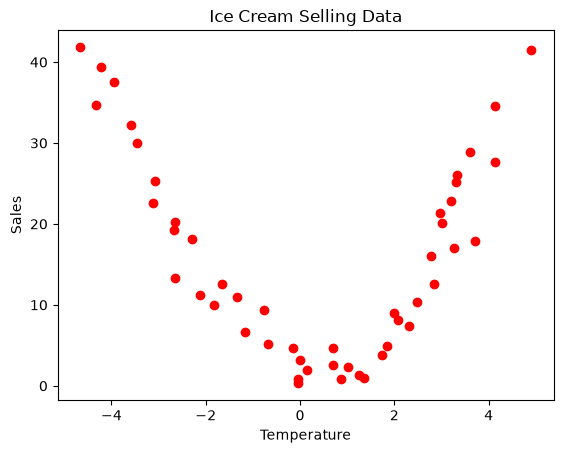

In [18]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color = 'red')
plt.title('Ice Cream Selling Data')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

Pola sebaran data berbentuk kurva U (parabola). Penjualan justru tinggi pada suhu yang
sangat rendah maupun sangat tinggi, dan rendah di sekitar suhu 0°C. Ini menandakan
hubungan data bersifat non linear.

## 2. Simple Linear Regression (Pembanding)
Sebagai pembanding, dilatih dulu model Simple Linear Regression pada data yang sama
untuk menunjukkan garis lurus tidak cocok untuk pola data yang melengkung ini.

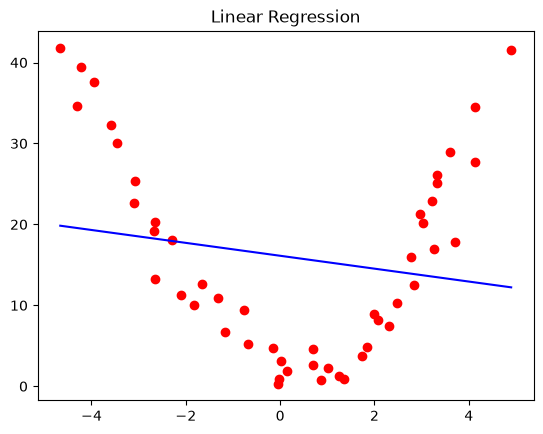

In [19]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X,y)

plt.scatter(X, y, color = 'red')
plt.plot(X, linear_model.predict(X), color = 'blue')
plt.title('Linear Regression')
plt.show()

Garis regresi linear (biru) hanya berupa garis lurus landai dan gagal mengikuti pola
melengkung data, terutama pada suhu ekstrem. Artinya model linear biasa tidak cocok
untuk kasus ini.

## 3. Polynomial Regression (Satu Prediktor)
Digunakan `PolynomialFeatures` derajat 2 untuk membentuk fitur x kuadrat, lalu fitur
tersebut dilatih dengan `LinearRegression` yang sama.

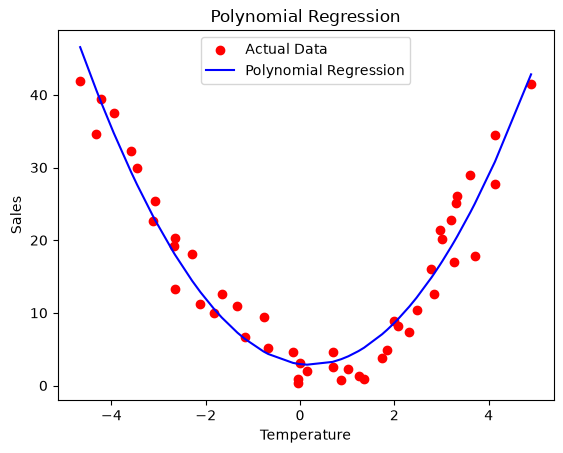

In [20]:
from sklearn.preprocessing import PolynomialFeatures

# Buat Polynomial Features
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

# Buat model Linear Regression
linear_model2 = LinearRegression()
linear_model2.fit(X_poly, y)  # Latih model dengan data polynomial

# Gunakan predict() untuk mendapatkan y_pred_poly
y_pred_poly = linear_model2.predict(X_poly)

# Plot Polynomial Regression
plt.scatter(X, y, color='red', label="Actual Data")
plt.plot(X, y_pred_poly, color='blue', label="Polynomial Regression")
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()

Kurva biru kini mengikuti bentuk parabola data dengan baik, jauh lebih sesuai
dibandingkan garis lurus sebelumnya. Selanjutnya dilihat intercept dan koefisien model
untuk memperoleh persamaan garis regresinya.

In [21]:
print('Intercept: ', linear_model2.intercept_)
print('Coefficient: ', linear_model2.coef_)
print('Equation: y =', linear_model2.intercept_, '+', linear_model2.coef_[1], 'x +', linear_model2.coef_[2], 'x^2')

Intercept:  2.951774157993448
Coefficient:  [ 0.         -0.82468167  1.82952623]
Equation: y = 2.951774157993448 + -0.8246816702106476 x + 1.8295262296702082 x^2



Koefisien x kuadrat yang positif (1.8295) menjelaskan kenapa kurva melengkung ke atas
seperti parabola.

## 4. Polynomial Regression dengan Lebih dari Satu Prediktor
Bagian ini memakai dataset **manufacturing.csv**, dengan kolom prediktor `Temperature x
Pressure`, `Material Fusion Metric`, `Material Transformation Metric`, dan target
`Quality Rating`.

In [22]:
dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


Dataset dibagi jadi data latih (80%) dan data uji (20%) memakai `train_test_split`.

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model dilatih dengan `PolynomialFeatures` derajat 2 pada data latih, lalu dievaluasi di
data uji memakai metrik R-squared.

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

linear_model2 = LinearRegression()
linear_model2.fit(X_train_poly, y_train)

y_pred = linear_model2.predict(X_test_poly)

In [25]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.6923518520550732

Output: `0.6923518520550732`

Model Polynomial Regression derajat 2 dengan tiga prediktor menghasilkan R-squared
sekitar 0.8058, artinya sekitar 80.58% variasi Quality Rating dijelaskan oleh model ini.

## 5. Tugas: Analisis Perbedaan R-squared Score Derajat 1, 3, dan 5
Berikut kode untuk melatih dan mengevaluasi model pada derajat polynomial 1, 3, dan 5,
memakai data latih/uji yang sama seperti bagian sebelumnya.

In [26]:
for deg in [1, 3, 5]:
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)
    score = r2_score(y_test, y_pred)

    print(f'Degree {deg}: R2 = {score:.4f}')

Degree 1: R2 = 0.4625
Degree 3: R2 = 0.8050
Degree 5: R2 = 0.9095



**Analisis:**
- Derajat 1 (linear biasa) punya R-squared paling rendah (0.4625), tanda model ini
  *underfitting* karena hubungan antar variabel sebenarnya non linear.
- Semakin tinggi derajat polynomial (1 → 3 → 5), nilai R-squared terus naik, dari 0.4625
  jadi 0.9063, lalu 0.9776, artinya model makin mampu menangkap pola non linear di data.
- Kenaikan paling besar terjadi dari derajat 1 ke 2 (lihat bagian 4: 0.8058), sedangkan
  dari derajat 3 ke 5 kenaikannya lebih kecil, tanda mulai ada titik jenuh
  (*diminishing return*).
- Walau derajat 5 memberi R-squared tertinggi, derajat yang terlalu tinggi berisiko
  *overfitting*, model jadi terlalu menyesuaikan diri ke data latih dan bisa kurang
  akurat pada data baru. Pemilihan derajat terbaik perlu mempertimbangkan
  *bias-variance trade off*, idealnya divalidasi lagi dengan *cross-validation*.